Autor: Daniel Sozoranga

# Reconocimiento de mi rostro con VGG-16 y transfer learning

En este cuaderno desarrollo un clasificador de imágenes con la red convolucional **VGG-16**. El modelo decide si una imagen contiene **mi rostro** o no. Tiene dos clases:

- **Fondo** (etiqueta 0): cualquier imagen que no contenga mi rostro, como lugares, objetos o la cara de otra persona.
- **Daniel** (etiqueta 1): imágenes donde aparece mi rostro.

El cuaderno sigue este orden: datos, etiquetas one-hot, división en entrenamiento y validación, construcción del modelo, entrenamiento, guardado y carga del modelo, predicción con imágenes nuevas, y las tres pruebas de la actividad calificable. Al final incluyo los experimentos de hiperparámetros.

> **Nota:** las fotos de mi rostro no se suben al repositorio por privacidad. Por eso este cuaderno se muestra ya ejecutado, con sus resultados visibles. El proyecto completo (scripts, aplicación de Streamlit y README) está en el repositorio.

## 1. Importar las bibliotecas

In [1]:
import os
import sys
import warnings
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # oculta los mensajes informativos de TensorFlow
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image

# El código reutilizable del proyecto está en la carpeta src
sys.path.insert(0, str(Path("..").resolve() / "src"))
from config import (CLASS_NAMES, IMG_SIZE, PROCESSED_DIR, MODEL_PATH, MODEL_DIR,
                    REPORT_DIR, ROOT, STUDENT_NAME, BACKGROUND_NAME)
from vgg_layer import VGGPreprocess   # capa que prepara la imagen al formato de VGG-16

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices("GPU"))
print("Clases (índice 0 y 1):", CLASS_NAMES)

I0000 00:00:1791326631.465144    9271 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1791326632.455546    9271 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Clases (índice 0 y 1): ['Fondo', 'Daniel']


## 2. Los datos

- **Daniel:** fotogramas de videos míos grabados con el celular y con la webcam, y fotos de mi galería.
- **Fondo:** fotos de lugares sin personas, rostros de otras personas de datasets públicos (LFW y FairFace) y rostros parecidos al mío.

Antes de entrenar, cada imagen pasa por un preprocesado: se detecta el rostro con el detector **YuNet**, se recorta, se pasa a blanco y negro con ecualización local del contraste (CLAHE) y se redimensiona a **224 × 224 píxeles**, que es el tamaño de entrada de VGG-16. El código está en `src/facecrop.py` y `src/crop_faces.py`.

Veamos cuántas imágenes hay de cada clase y algunos ejemplos ya preprocesados:

In [2]:
for clase in CLASS_NAMES:
    n = len(list((PROCESSED_DIR / clase).glob("*.jpg")))
    print(f"{clase}: {n} imágenes")

Fondo: 5364 imágenes
Daniel: 2770 imágenes


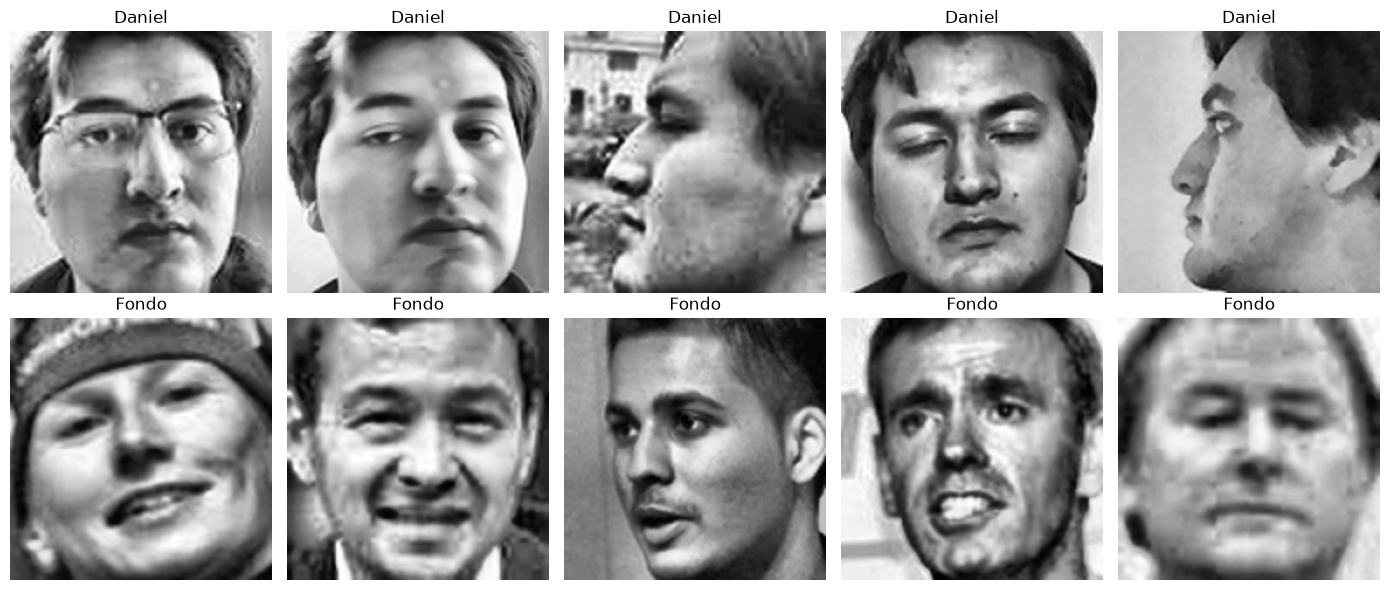

In [3]:
import random
random.seed(0)
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for fila, clase in enumerate([STUDENT_NAME, BACKGROUND_NAME]):
    archivos = sorted((PROCESSED_DIR / clase).glob("*.jpg"))
    for ax, f in zip(axes[fila], random.sample(archivos, 5)):
        ax.imshow(plt.imread(f))
        ax.set_title(clase)
        ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Etiquetas one-hot y división en entrenamiento y validación

Las etiquetas se convierten a formato **one-hot** con `label_mode="categorical"`: cada imagen queda con un vector de dos posiciones, una para Fondo y otra para Daniel.

Los datos se dividen con `validation_split=0.2`: el **80 %** se usa para entrenar y el **20 %** para validar.

In [4]:
BATCH = 16   # tamaño de lote

def cargar_datos(batch_size=BATCH, val_split=0.2, seed=42):
    kw = dict(
        directory=PROCESSED_DIR,
        class_names=CLASS_NAMES,
        label_mode="categorical",      # etiquetas en one-hot
        image_size=IMG_SIZE,           # 224 x 224
        crop_to_aspect_ratio=True,
        batch_size=batch_size,
        validation_split=val_split,    # 80 % entrenamiento, 20 % validación
        seed=seed,
    )
    train = keras.utils.image_dataset_from_directory(subset="training", **kw)
    val = keras.utils.image_dataset_from_directory(subset="validation", **kw)
    return train, val

train_ds, val_ds = cargar_datos()
print("Imágenes de entrenamiento:", len(train_ds.file_paths))
print("Imágenes de validación:", len(val_ds.file_paths))

x, y = next(iter(train_ds))
print("Forma de un lote de imágenes:", x.shape)
print("Etiquetas one-hot de las primeras 5 imágenes (columna 0 = Fondo, columna 1 = Daniel):")
print(y.numpy()[:5])

train_pf = train_ds.prefetch(tf.data.AUTOTUNE)
val_pf = val_ds.prefetch(tf.data.AUTOTUNE)

Found 8134 files belonging to 2 classes.


Using 6508 files for training.


Found 8134 files belonging to 2 classes.


Using 1626 files for validation.


Imágenes de entrenamiento: 6508
Imágenes de validación: 1626
Forma de un lote de imágenes: (16, 224, 224, 3)
Etiquetas one-hot de las primeras 5 imágenes (columna 0 = Fondo, columna 1 = Daniel):
[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]


## 4. Construir el modelo VGG-16 (transfer learning)

- Cargo **VGG-16 con los pesos de ImageNet** (`weights="imagenet"`) y sin sus capas superiores (`include_top=False`).
- **Congelo la base** (`trainable = False`): sus pesos no cambian durante el entrenamiento, y solo se entrenan las capas nuevas.
- Encima agrego mi propia cabeza de clasificación: `Flatten`, `Dense(256, ReLU)`, `Dropout(0.5)` y `Dense(2, softmax)`.
- Antes de la base hay una capa de **aumento de datos** (giros, zoom, brillo, contraste), que solo actúa durante el entrenamiento.
- Compilo con la pérdida `categorical_crossentropy` y el optimizador `Adam`.

In [5]:
def construir_modelo(lr=1e-4):
    # Aumento de datos: solo se aplica durante el entrenamiento
    aumento = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
        layers.RandomTranslation(0.1, 0.1),
        layers.RandomBrightness(0.2),
        layers.RandomContrast(0.2),
    ], name="augment")

    # Base VGG-16 preentrenada en ImageNet, sin las capas superiores, y congelada
    base = VGG16(weights="imagenet", include_top=False, input_shape=IMG_SIZE + (3,))
    base.trainable = False

    entradas = keras.Input(shape=IMG_SIZE + (3,))
    x = aumento(entradas)
    x = VGGPreprocess(name="vgg_preprocess")(x)   # imagen RGB -> formato que espera VGG-16
    x = base(x, training=False)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)                    # apaga al azar el 50 % de las unidades
    salidas = layers.Dense(len(CLASS_NAMES), activation="softmax")(x)   # 2 clases

    modelo = keras.Model(entradas, salidas)
    modelo.compile(loss="categorical_crossentropy",
                   optimizer=keras.optimizers.Adam(learning_rate=lr),
                   metrics=["accuracy"])
    return modelo

modelo = construir_modelo()
modelo.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment (Sequential)            │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg_preprocess (VGGPreprocess)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,986 (80.64 MB)

 Trainable params: 6,423,298 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## 5. Entrenamiento

Uso **EarlyStopping** sobre `val_loss`: si la pérdida de validación no mejora durante 8 épocas seguidas, el entrenamiento se detiene y se restauran los mejores pesos. **ModelCheckpoint** guarda el mejor modelo. También calculo **pesos por clase**, porque hay más imágenes de Fondo que de Daniel.

El modelo final de este proyecto se entrenó con el script `src/train.py`: **15 épocas** con la base congelada y **10 épocas más** de fine-tuning del último bloque convolucional (bloque 5), que tardó unos 20 minutos. Para que este cuaderno se ejecute rápido, aquí hago un **entrenamiento de demostración de 3 épocas**; después cargo el modelo final ya entrenado para evaluarlo.

In [6]:
conteos = np.array([len(list((PROCESSED_DIR / c).glob("*"))) for c in CLASS_NAMES], dtype=float)
pesos_clase = {i: conteos.sum() / (len(conteos) * n) for i, n in enumerate(conteos)}
print("Pesos por clase:", {CLASS_NAMES[i]: round(p, 2) for i, p in pesos_clase.items()})

ruta_demo = MODEL_DIR / "modelo_notebook_demo.keras"
early_stopping = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
checkpoint = ModelCheckpoint(ruta_demo, monitor="val_loss", save_best_only=True)

EPOCAS_DEMO = 3
historia = modelo.fit(train_pf, validation_data=val_pf, epochs=EPOCAS_DEMO,
                      class_weight=pesos_clase, callbacks=[early_stopping, checkpoint], verbose=2)

Pesos por clase: {'Fondo': np.float64(0.76), 'Daniel': np.float64(1.47)}
Epoch 1/3


407/407 - 40s - 99ms/step - accuracy: 0.8162 - loss: 1.2569 - val_accuracy: 0.8856 - val_loss: 0.3240


Epoch 2/3


407/407 - 37s - 91ms/step - accuracy: 0.8746 - loss: 0.3108 - val_accuracy: 0.9459 - val_loss: 0.1352


Epoch 3/3


407/407 - 35s - 85ms/step - accuracy: 0.9096 - loss: 0.2302 - val_accuracy: 0.9526 - val_loss: 0.1097


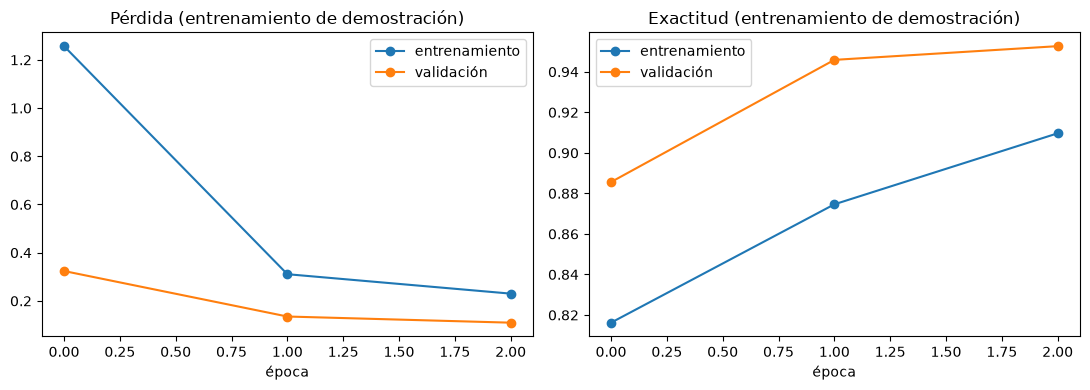

Pérdida de validación: 0.1097
Exactitud de validación: 0.9526


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, k, t in zip(ax, ["loss", "accuracy"], ["Pérdida", "Exactitud"]):
    a.plot(historia.history[k], marker="o", label="entrenamiento")
    a.plot(historia.history["val_" + k], marker="o", label="validación")
    a.set_title(t + " (entrenamiento de demostración)")
    a.set_xlabel("época")
    a.legend()
plt.tight_layout()
plt.show()

perdida, exactitud = modelo.evaluate(val_pf, verbose=0)
print(f"Pérdida de validación: {perdida:.4f}")
print(f"Exactitud de validación: {exactitud:.4f}")

## 6. Guardar y cargar el modelo

El modelo se guarda en el formato nativo de Keras, `.keras`. Después se carga con `load_model`, sin necesidad de volver a entrenar.

In [8]:
# Modelo del entrenamiento de demostración (guardado por ModelCheckpoint)
print("Archivo de la demostración:", ruta_demo.name, f"({os.path.getsize(ruta_demo) / 1e6:.0f} MB)")
modelo_demo = keras.models.load_model(ruta_demo)
print("Modelo de demostración cargado correctamente.")

# Modelo final del proyecto: 15 épocas + 10 de fine-tuning
print("Archivo del modelo final:", MODEL_PATH.name, f"({os.path.getsize(MODEL_PATH) / 1e6:.0f} MB)")
modelo_final = keras.models.load_model(MODEL_PATH)
print("Modelo final cargado correctamente.")

Archivo de la demostración: modelo_notebook_demo.keras (136 MB)


Modelo de demostración cargado correctamente.
Archivo del modelo final: modelo_rostro.keras (193 MB)


Modelo final cargado correctamente.


## 7. Evaluación del modelo final

Evalúo el modelo final con el conjunto de validación (el 20 % de las imágenes). Muestro el reporte de clasificación, la matriz de confusión y las curvas del entrenamiento completo.

              precision    recall  f1-score   support

       Fondo       1.00      1.00      1.00      1072
      Daniel       0.99      1.00      0.99       554

    accuracy                           1.00      1626
   macro avg       1.00      1.00      1.00      1626
weighted avg       1.00      1.00      1.00      1626

Exactitud: 99.6%


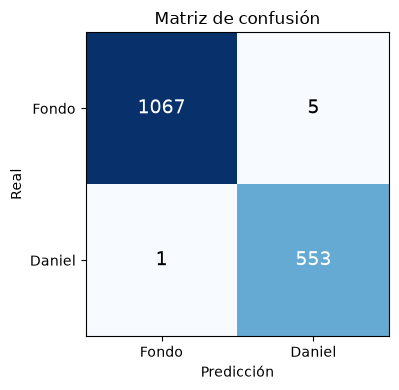

In [9]:
lotes = list(val_ds)
x_val = np.concatenate([x.numpy() for x, _ in lotes])
y_real = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in lotes])
y_pred = np.argmax(modelo_final.predict(x_val, verbose=0), axis=1)

print(classification_report(y_real, y_pred, target_names=CLASS_NAMES))
print(f"Exactitud: {(y_real == y_pred).mean():.1%}")

cm = confusion_matrix(y_real, y_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(2), CLASS_NAMES)
ax.set_yticks(range(2), CLASS_NAMES)
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)
ax.set_title("Matriz de confusión")
plt.tight_layout()
plt.show()

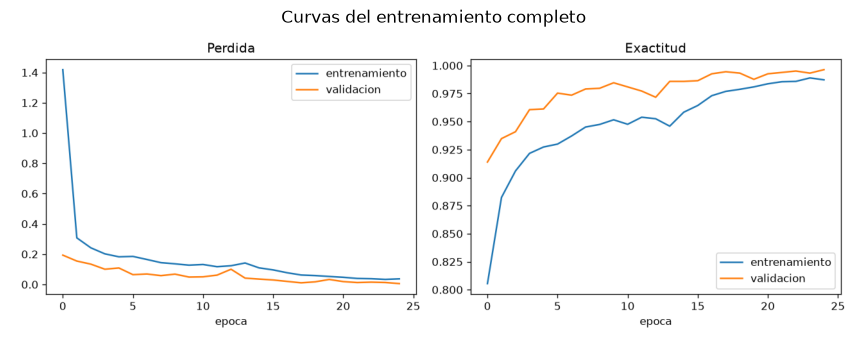

In [10]:
# Curvas del entrenamiento completo (15 épocas + 10 de fine-tuning), generadas por src/train.py
curvas = plt.imread(REPORT_DIR / "curvas_entrenamiento.png")
plt.figure(figsize=(11, 4))
plt.imshow(curvas)
plt.axis("off")
plt.title("Curvas del entrenamiento completo")
plt.show()

## 8. Predicción con una imagen nueva

Hago una predicción con una foto mía que **no se usó para entrenar**. El modelo siempre espera un **lote** de imágenes y devuelve un lote de predicciones, por eso se usa `np.expand_dims` y se accede con `pred[0]`.

- `pred[0][0]` es la probabilidad de que la imagen sea **Fondo**.
- `pred[0][1]` es la probabilidad de que la imagen sea **Daniel**.

Primero se detecta el rostro y se prepara igual que en el entrenamiento.

[[2.4578896e-12 1.0000000e+00]]
Probabilidad de Fondo: 0.0000
Probabilidad de Daniel: 1.0000


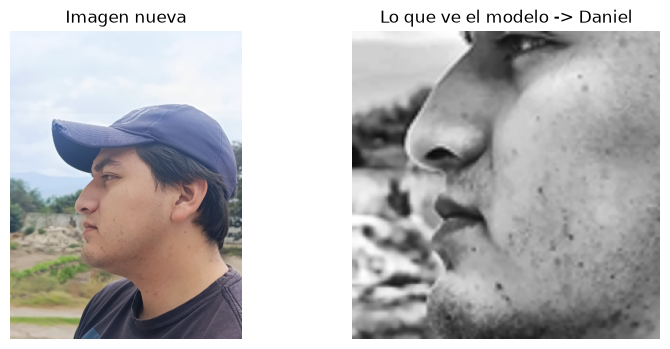

In [11]:
from facecrop import detect_faces, crop_box, normalize_resolution

ruta = sorted((ROOT / "pruebas" / "daniel_nuevas").glob("*"))[0]
img = Image.open(ruta).convert("RGB")

cajas = detect_faces(img)
cara = normalize_resolution(crop_box(img, cajas[0]), IMG_SIZE)

lote = np.expand_dims(np.asarray(cara, dtype="float32"), axis=0)   # forma (1, 224, 224, 3)
pred = modelo_final.predict(lote, verbose=0)
print(pred)
print(f"Probabilidad de Fondo: {pred[0][0]:.4f}")
print(f"Probabilidad de Daniel: {pred[0][1]:.4f}")

etiqueta = STUDENT_NAME if pred[0][1] > pred[0][0] else BACKGROUND_NAME
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(img); ax[0].set_title("Imagen nueva"); ax[0].axis("off")
ax[1].imshow(cara); ax[1].set_title(f"Lo que ve el modelo -> {etiqueta}"); ax[1].axis("off")
plt.show()

## 9. Actividad calificable: las tres pruebas

Las tres pruebas se hacen con imágenes que **no están en la carpeta de entrenamiento**:

1. **Foto del estudiante** (en la presentación se toma con la webcam). Etiqueta requerida: **Daniel**.
2. **Un fondo nuevo**. Etiqueta requerida: **Fondo**.
3. **Foto de un rostro diferente al mío**. Etiqueta requerida: **Fondo**.

En la aplicación y en este cuaderno, una imagen se clasifica como Daniel si **algún** rostro detectado supera el umbral de 0.8; si no hay rostros, se analiza la imagen completa. La lógica está en `src/inference.py`.

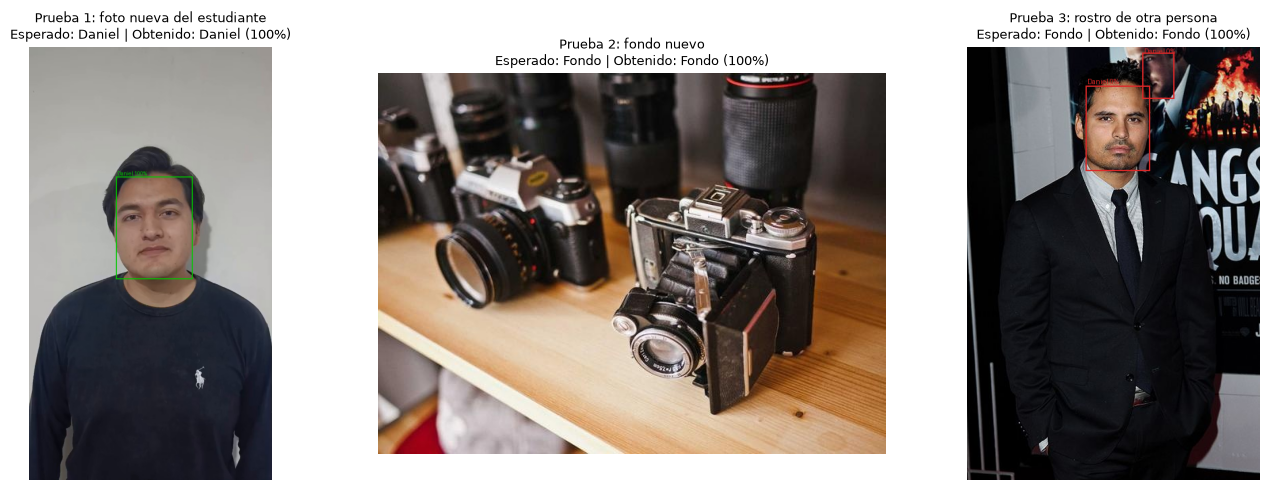

In [12]:
from inference import classify, annotate

def primera(carpeta):
    return sorted((ROOT / "pruebas" / carpeta).glob("*"))[0]

casos = [
    ("Prueba 1: foto nueva del estudiante", "daniel", STUDENT_NAME),
    ("Prueba 2: fondo nuevo", "lugares", BACKGROUND_NAME),
    ("Prueba 3: rostro de otra persona", "celebridades", BACKGROUND_NAME),
]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (titulo, carpeta, esperado) in zip(axes, casos):
    img = Image.open(primera(carpeta)).convert("RGB")
    res = classify(modelo_final, img)
    ax.imshow(annotate(img, res))
    ax.set_title(f"{titulo}\nEsperado: {esperado} | Obtenido: {res['label']} ({res['confidence']:.0%})", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [13]:
# Resultados con todas las imágenes de prueba (nunca usadas para entrenar)
grupos = [
    ("daniel", STUDENT_NAME, "Fotos nuevas mías (video aparte)"),
    ("daniel_nuevas", STUDENT_NAME, "Fotos nuevas mías (galería)"),
    ("lugares", BACKGROUND_NAME, "Lugares nuevos"),
    ("celebridades", BACKGROUND_NAME, "Rostros de celebridades"),
    ("celebridades2", BACKGROUND_NAME, "Rostros parecidos al mío (2)"),
    ("celebridades3", BACKGROUND_NAME, "Rostros parecidos al mío (3)"),
]
total_ok = total = 0
for carpeta, esperado, nombre in grupos:
    archivos = sorted(p for p in (ROOT / "pruebas" / carpeta).glob("*")
                      if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"})
    ok = sum(classify(modelo_final, Image.open(p).convert("RGB"))["label"] == esperado for p in archivos)
    total_ok, total = total_ok + ok, total + len(archivos)
    print(f"{nombre:36s} esperado {esperado:7s} -> {ok}/{len(archivos)} aciertos")
print(f"\nTotal: {total_ok}/{total} ({total_ok / total:.0%})")

Fotos nuevas mías (video aparte)     esperado Daniel  -> 56/56 aciertos


Fotos nuevas mías (galería)          esperado Daniel  -> 8/8 aciertos


Lugares nuevos                       esperado Fondo   -> 10/10 aciertos


Rostros de celebridades              esperado Fondo   -> 7/7 aciertos


Rostros parecidos al mío (2)         esperado Fondo   -> 3/3 aciertos


Rostros parecidos al mío (3)         esperado Fondo   -> 5/6 aciertos

Total: 89/90 (99%)


## 10. Prueba de hiperparámetros (opcional)

Para ver el efecto de los hiperparámetros entrené **siete modelos cortos** (10 épocas), cambiando **una sola cosa** respecto a una referencia (Adam, tasa 1e-4, lote 16, `categorical_crossentropy`, con aumento de datos). Los scripts son `run_experiments.sh` y `src/compare_experiments.py`. Los modelos se evaluaron con las mismas imágenes de prueba:

In [14]:
from IPython.display import Markdown, display
display(Markdown((REPORT_DIR / "experimentos.md").read_text(encoding="utf-8")))

| Modelo | Tus fotos (video 4) | Tus fotos (galeria) | Lugares | Celebridades | Parecidos 2 | Parecidos 3 | Total |
|---|---|---|---|---|---|---|---|
| principal | 56/56 | 8/8 | 10/10 | 7/7 | 3/3 | 5/6 | 89/90 (99%) |
| epocas3 | 56/56 | 8/8 | 10/10 | 5/7 | 2/3 | 4/6 | 85/90 (94%) |
| lote32 | 56/56 | 8/8 | 10/10 | 5/7 | 2/3 | 5/6 | 86/90 (96%) |
| perdida_mse | 56/56 | 8/8 | 10/10 | 3/7 | 0/3 | 2/6 | 79/90 (88%) |
| referencia | 56/56 | 4/8 | 10/10 | 5/7 | 2/3 | 4/6 | 81/90 (90%) |
| rmsprop | 56/56 | 8/8 | 10/10 | 6/7 | 2/3 | 5/6 | 87/90 (97%) |
| sgd | 56/56 | 8/8 | 10/10 | 4/7 | 1/3 | 5/6 | 84/90 (93%) |
| sin_aumento | 55/56 | 5/8 | 10/10 | 7/7 | 2/3 | 6/6 | 85/90 (94%) |


**Qué cambié en cada modelo:** `sgd` y `rmsprop` (optimizador), `lote32` (tamaño de lote), `perdida_mse` (función de pérdida), `sin_aumento` (sin aumento de datos), `epocas3` (3 épocas en vez de 10), `referencia` (la configuración base) y `principal` (el entrenamiento completo: 15 épocas más 10 de fine-tuning).

**Conclusiones:**

- La **función de pérdida** es lo que más importa: `mean_squared_error` fue la peor configuración.
- El modelo **principal** es el mejor, no por un hiperparámetro aislado, sino por todo el procedimiento: más épocas, fine-tuning del bloque 5 y búsqueda de rostros difíciles (*hard negative mining*).
- Entre los **optimizadores** la diferencia fue pequeña y no es concluyente, porque los conjuntos de prueba son chicos.
- **Sin aumento de datos** la exactitud de validación sube, pero con imágenes nuevas el resultado no mejora.

## 11. Conclusiones y mejoras posibles

- Con **transfer learning** sobre VGG-16 (base congelada, cabeza propia y fine-tuning del último bloque) el modelo distingue mi rostro del resto con una exactitud de validación cercana al 99.6 %, y **supera las tres pruebas de la actividad** con imágenes nuevas.
- **Mejoras posibles:** agregar más rostros parecidos al mío en la clase Fondo y más fotos mías en condiciones distintas (otras épocas, luces y poses) haría al modelo todavía más robusto.
- La **aplicación de Streamlit** (`app.py`) permite subir una imagen o tomar una foto con la webcam, y dibuja un cuadro por rostro con su probabilidad.